# **RA01 - Bootstrap d'une courbe de taux OIS (EUR)**

Ce notebook illustre la construction d'une courbe de discount par bootstrapping à partir d'instruments de marché réels.

**Contexte** : courbe €STR (Euro Short-Term Rate), janvier 2024 — environnement de taux élevés post-resserrement BCE.

**Instruments utilisés** :
- Dépôts (court terme, 0 à 6 mois)
- Swaps OIS annuels (1 à 10 ans)

**Ce qu'on va vérifier** :
1. Les piliers bootstrappés sont cohérents
2. La courbe de discount est décroissante
3. Les taux zéro reflètent la structure de taux du marché
4. Les taux forward captent les anticipations implicites
5. Log-linéaire vs cubic spline : impact de l'interpolation

In [9]:
from datetime import date
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from JR_PRICER.instruments.deposit import Deposit
from JR_PRICER.instruments.swap import OISSwap
from JR_PRICER.instruments.leg import FixedLeg, FloatingLeg
from JR_PRICER.market_data.quote import Quote
from JR_PRICER.curves.bootstrap import BootstrapBuilder
from JR_PRICER.curves.interpolators_1D.log_linear import LogLinearInterpolator1D
from JR_PRICER.curves.interpolators_1D.cubic_splines import ScipyCubicSplinesInterpolator1D
from JR_PRICER.utils.day_count import DayCounter
from JR_PRICER.utils.frequency import Frequency
from JR_PRICER.utils.calendar import TARGET
from JR_PRICER.utils.business_day_convention import BusinessDayConvention

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

## 1. Données de marché

Taux €STR approximatifs au 15 janvier 2024 (taux BCE à 4%, marché anticipant des baisses).

| Instrument | Maturité | Taux |
|------------|----------|------|
| Dépôt ON   | 16/01/24 | 3.904% |
| Dépôt 1W   | 22/01/24 | 3.900% |
| Dépôt 1M   | 15/02/24 | 3.880% |
| Dépôt 3M   | 15/04/24 | 3.850% |
| Dépôt 6M   | 15/07/24 | 3.780% |
| OIS 1Y     | 15/01/25 | 3.600% |
| OIS 2Y     | 15/01/26 | 3.300% |
| OIS 3Y     | 15/01/27 | 3.050% |
| OIS 5Y     | 15/01/29 | 2.850% |
| OIS 7Y     | 15/01/31 | 2.750% |
| OIS 10Y    | 15/01/34 | 2.700% |

In [10]:
reference_date = date(2024, 1, 15)
day_count      = DayCounter('act/360')
calendar       = TARGET()
convention     = BusinessDayConvention.MODIFIED_FOLLOWING

# ── Dépôts (settlement = reference_date, T+0) ────────────────────────────────
deposits = [
    Deposit(Quote(0.03904), date(2024,  1, 16), day_count, reference_date),  # ON
    Deposit(Quote(0.03900), date(2024,  1, 22), day_count, reference_date),  # 1W
    Deposit(Quote(0.03880), date(2024,  2, 15), day_count, reference_date),  # 1M
    Deposit(Quote(0.03850), date(2024,  4, 15), day_count, reference_date),  # 3M
    Deposit(Quote(0.03780), date(2024,  7, 15), day_count, reference_date),  # 6M
]

# ── Swaps OIS (paiement annuel, Act/360) ──────────────────────────────────────
def make_ois(rate: float, maturity: date) -> OISSwap:
    q = Quote(rate)
    return OISSwap(
        start_date   = reference_date,
        maturity_date= maturity,
        notional     = 1_000_000,
        fixed_leg    = FixedLeg(day_count, Frequency.ANNUAL, q),
        floating_leg = FloatingLeg(day_count, Frequency.ANNUAL, q),
        calendar     = calendar,
        convention   = convention,
    )

swaps = [
    make_ois(0.03600, date(2025, 1, 15)),  # 1Y
    make_ois(0.03300, date(2026, 1, 15)),  # 2Y
    make_ois(0.03050, date(2027, 1, 15)),  # 3Y
    make_ois(0.02850, date(2029, 1, 15)),  # 5Y
    make_ois(0.02750, date(2031, 1, 15)),  # 7Y
    make_ois(0.02700, date(2034, 1, 15)),  # 10Y
]

instruments = deposits + swaps
print(f"{len(instruments)} instruments chargés ({len(deposits)} dépôts, {len(swaps)} swaps)")

11 instruments chargés (5 dépôts, 6 swaps)


## 2. Bootstrap

In [11]:
builder = BootstrapBuilder(
    instruments          = instruments,
    interpolator         = LogLinearInterpolator1D(),
    day_count_convention = day_count,
    reference_date       = reference_date,
)
curve = builder.bootstrap()

print(f"{'T (années)':>12}  {'Discount Factor':>16}  {'Taux zéro':>12}")
print("-" * 46)
for t, df in zip(curve.times[1:], curve.values[1:]):   # skip l'ancre (0, 1)
    z = -np.log(df) / t * 100
    print(f"{t:>12.4f}  {df:>16.6f}  {z:>11.4f}%")

  T (années)   Discount Factor     Taux zéro
----------------------------------------------
      0.0028          0.999892       3.9038%
      0.0194          0.999242       3.8985%
      0.0861          0.996670       3.8735%
      0.2528          0.990362       3.8314%
      0.5056          0.981248       3.7443%
      1.0167          0.964692       3.5357%
      2.0306          0.936307       3.2411%
      3.0444          0.912902       2.9932%
      5.0750          0.867751       2.7951%
      7.1028          0.825778       2.6951%
     10.1472          0.764330       2.6486%


## 3. Visualisations

### 3.1 Courbe de discount

P(0, T) doit être strictement décroissante de 1 vers 0. Les points noirs sont les piliers bootstrappés.

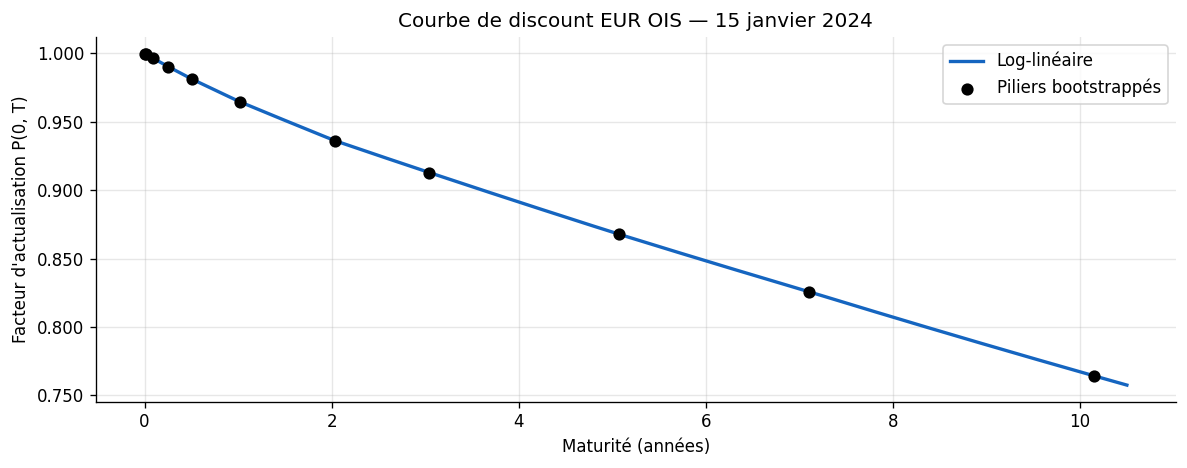

In [12]:
T_grid = np.linspace(0.01, 10.5, 500)
df_grid = np.array([curve.discount(t) for t in T_grid])

pillar_T  = np.array(curve.times[1:])
pillar_df = np.array(curve.values[1:])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(T_grid, df_grid, color='#1565C0', linewidth=2, label='Log-linéaire')
ax.scatter(pillar_T, pillar_df, color='black', zorder=5, s=40, label='Piliers bootstrappés')
ax.set_xlabel('Maturité (années)')
ax.set_ylabel('Facteur d\'actualisation P(0, T)')
ax.set_title('Courbe de discount EUR OIS — 15 janvier 2024')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
plt.tight_layout()
plt.show()

### 3.2 Courbe de taux zéro

Le taux zéro z(T) = -ln P(0,T) / T donne le rendement d'une obligation zéro-coupon. On superpose les taux de marché pour vérifier la cohérence du bootstrap.

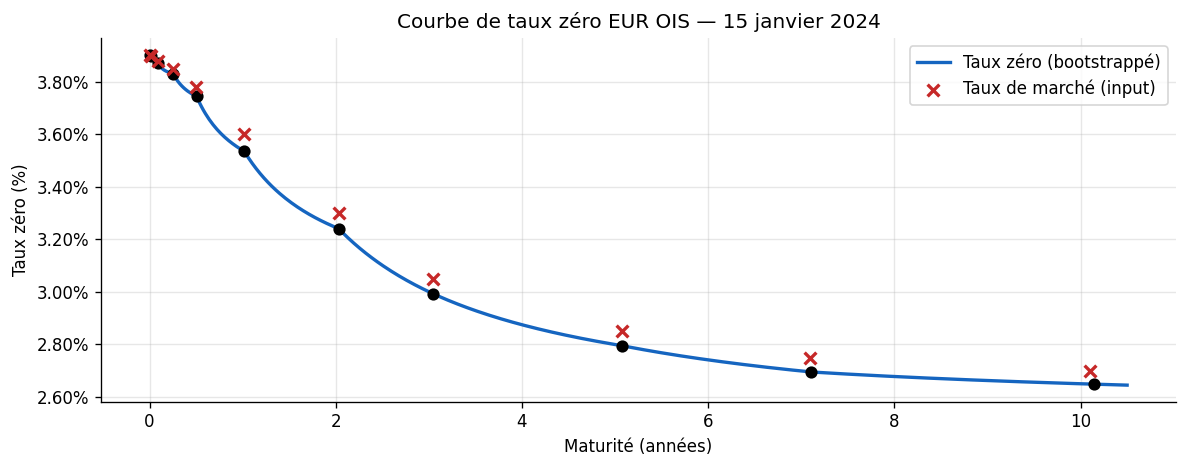

In [13]:
zero_grid = np.array([curve.zero_rate(t) * 100 for t in T_grid])
pillar_zero = -np.log(pillar_df) / pillar_T * 100

# Taux de marché bruts pour overlay
market_T     = [1/360, 7/360, 31/360, 91/360, 181/360, 1.017, 2.031, 3.044, 5.072, 7.089, 10.106]
market_rates = [3.904, 3.900, 3.880, 3.850, 3.780, 3.600, 3.300, 3.050, 2.850, 2.750, 2.700]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(T_grid, zero_grid, color='#1565C0', linewidth=2, label='Taux zéro (bootstrappé)')
ax.scatter(pillar_T, pillar_zero, color='black', zorder=5, s=40)
ax.scatter(market_T, market_rates, color='#C62828', zorder=6, s=50,
           marker='x', linewidths=2, label='Taux de marché (input)')
ax.set_xlabel('Maturité (années)')
ax.set_ylabel('Taux zéro (%)')
ax.set_title('Courbe de taux zéro EUR OIS — 15 janvier 2024')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f%%'))
plt.tight_layout()
plt.show()

### 3.3 Taux forward 1Y

Le taux forward f(t, t+1) est le taux implicitement anticipé par le marché pour la période [t, t+1]. 
On lit ici les baisses de taux attendues après 2024.

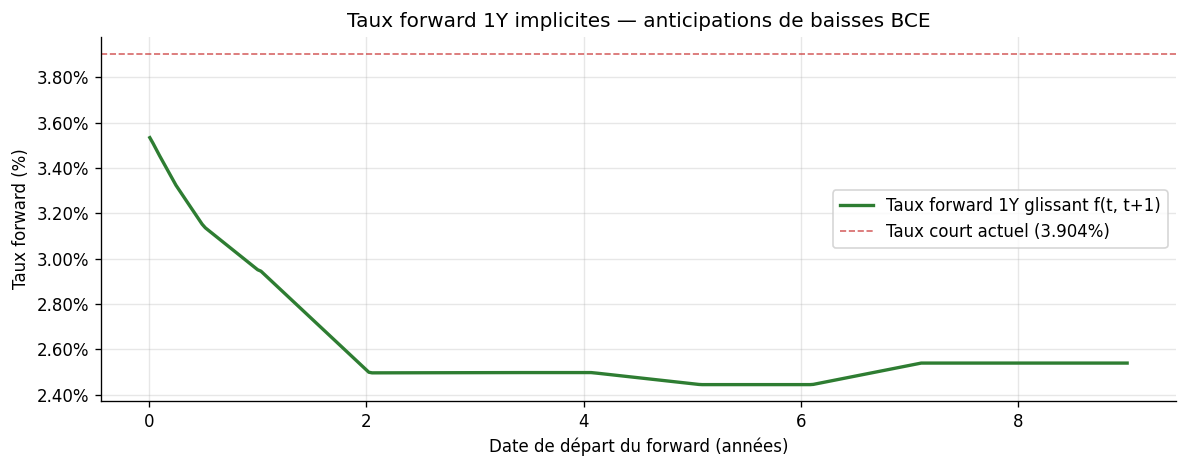

In [14]:
fwd_start = np.linspace(0.01, 9.0, 300)
fwd_1y = np.array([curve.forward_rate(t, t + 1.0) * 100 for t in fwd_start])

# Taux forward discrets aux piliers (pour overlay)
fwd_pillar_T, fwd_pillar_r = [], []
for i in range(len(pillar_T) - 1):
    mid = (pillar_T[i] + pillar_T[i+1]) / 2
    fwd = curve.forward_rate(pillar_T[i], pillar_T[i+1]) * 100
    fwd_pillar_T.append(mid)
    fwd_pillar_r.append(fwd)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(fwd_start, fwd_1y, color='#2E7D32', linewidth=2, label='Taux forward 1Y glissant f(t, t+1)')
ax.axhline(y=3.904, color='#C62828', linestyle='--', linewidth=1, alpha=0.7, label='Taux court actuel (3.904%)')
ax.set_xlabel('Date de départ du forward (années)')
ax.set_ylabel('Taux forward (%)')
ax.set_title('Taux forward 1Y implicites — anticipations de baisses BCE')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f%%'))
plt.tight_layout()
plt.show()

## 4. Impact de l'interpolation : log-linéaire vs cubic spline

Les deux interpolateurs donnent la même courbe **aux piliers** (c'est une propriété du bootstrap). 
La différence apparaît **entre les piliers** — l'écart se lit directement sur les taux forward.

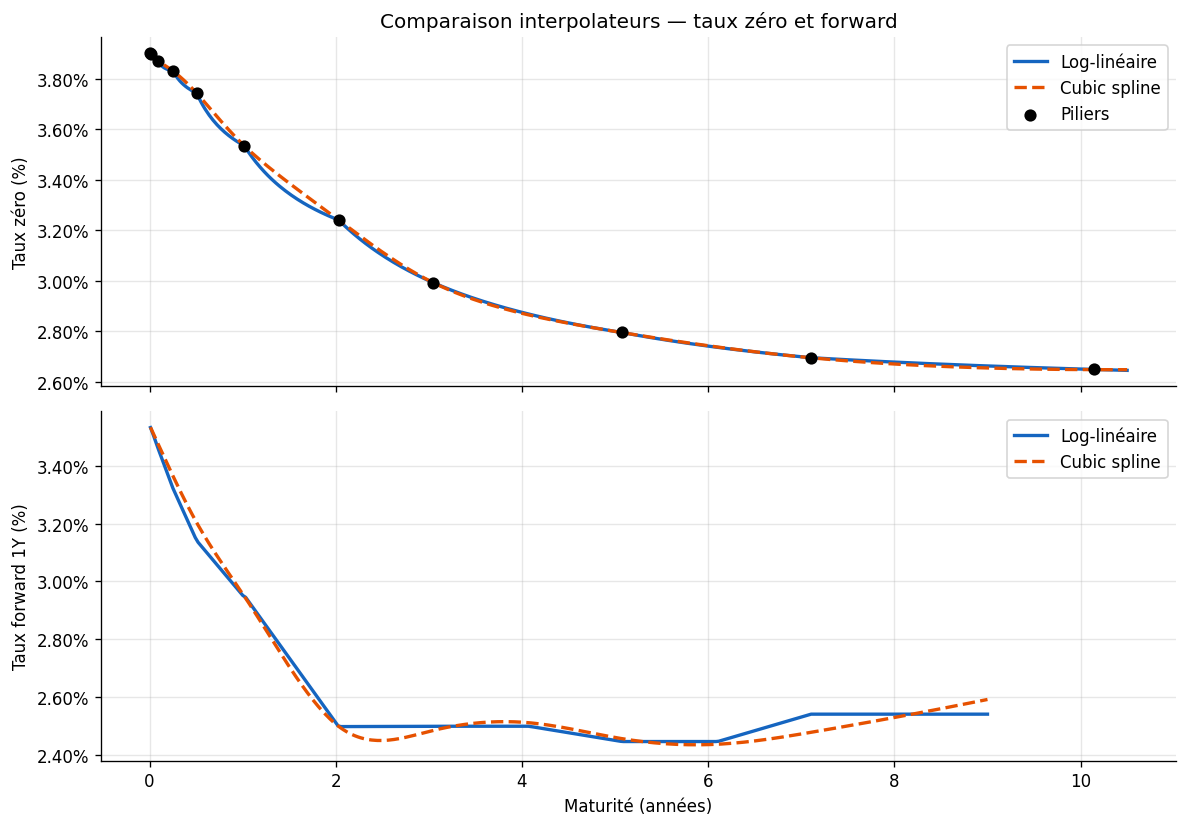

Écart max sur taux zéro  : 0.0418 bps
Écart max sur taux fwd 1Y: 0.0629 bps


In [15]:
curve_cs = BootstrapBuilder(
    instruments          = instruments,
    interpolator         = ScipyCubicSplinesInterpolator1D(),
    day_count_convention = day_count,
    reference_date       = reference_date,
).bootstrap()

zero_ll = np.array([curve.zero_rate(t)    * 100 for t in T_grid])
zero_cs = np.array([curve_cs.zero_rate(t) * 100 for t in T_grid])

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# — Taux zéro ——
ax = axes[0]
ax.plot(T_grid, zero_ll, color='#1565C0', linewidth=2, label='Log-linéaire')
ax.plot(T_grid, zero_cs, color='#E65100', linewidth=2, linestyle='--', label='Cubic spline')
ax.scatter(pillar_T, pillar_zero, color='black', zorder=5, s=40, label='Piliers')
ax.set_ylabel('Taux zéro (%)')
ax.set_title('Comparaison interpolateurs — taux zéro et forward')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f%%'))

# — Taux forward 1Y ——
ax = axes[1]
fwd_cs = np.array([curve_cs.forward_rate(t, t + 1.0) * 100 for t in fwd_start])
ax.plot(fwd_start, fwd_1y, color='#1565C0', linewidth=2, label='Log-linéaire')
ax.plot(fwd_start, fwd_cs,  color='#E65100', linewidth=2, linestyle='--', label='Cubic spline')
ax.set_xlabel('Maturité (années)')
ax.set_ylabel('Taux forward 1Y (%)')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f%%'))

plt.tight_layout()
plt.show()

print("Écart max sur taux zéro  :", round(np.max(np.abs(zero_cs - zero_ll)), 4), "bps")
print("Écart max sur taux fwd 1Y:", round(np.max(np.abs(fwd_cs  - fwd_1y)), 4), "bps")

## 5. Vérification : les swaps pricent-ils à zéro ?

Un swap bootstrappé doit avoir une valeur de marché nulle (il est à la monnaie par construction). On vérifie ici que le PV du fixed leg = PV du floating leg pour chaque swap input.

In [16]:
def price_fixed_leg(swap, curve):
    """PV du fixed leg (notionnel 1)."""
    r   = swap.fixed_leg.fixed_rate.value()
    dc  = swap.fixed_leg.day_count_convention
    all_dates = [swap.start_date] + swap.fixed_leg_dates
    pv = 0.0
    for d_start, d_end in zip(all_dates[:-1], all_dates[1:]):
        tau = dc.year_fraction(d_start, d_end)
        T   = curve.day_count_convention.year_fraction(curve.reference_date, d_end)
        pv += r * tau * curve.discount(T)
    # remboursement notionnel à maturité
    T_mat = curve.day_count_convention.year_fraction(curve.reference_date, swap.maturity_date)
    pv += curve.discount(T_mat)
    return pv

print(f"{'Swap':>6}  {'PV fixed leg':>14}  {'PV float (≈ 1)':>14}  {'Erreur (bps)':>14}")
print("-" * 56)
labels = ['1Y', '2Y', '3Y', '5Y', '7Y', '10Y']
for label, swap in zip(labels, swaps):
    pv_fixed = price_fixed_leg(swap, curve)
    # floating leg at-the-money = 1 (par swap → PV float = notionnel)
    err_bps = abs(pv_fixed - 1.0) * 10_000
    print(f"{label:>6}  {pv_fixed:>14.8f}  {'1.00000000':>14}  {err_bps:>13.4f}")

  Swap    PV fixed leg  PV float (≈ 1)    Erreur (bps)
--------------------------------------------------------
    1Y      1.00000000      1.00000000         0.0000
    2Y      1.00000000      1.00000000         0.0000
    3Y      1.00000000      1.00000000         0.0000
    5Y      0.99999968      1.00000000         0.0032
    7Y      1.00001269      1.00000000         0.1269
   10Y      0.99993545      1.00000000         0.6455


### Analyse des erreurs de re-pricing

Les résultats montrent un écart croissant avec la maturité : **0 bps pour 1Y–3Y, puis 0.003, 0.13 et 0.65 bps pour 5Y, 7Y, 10Y**. Ce n'est pas un bug — c'est une conséquence structurelle du bootstrap séquentiel.

#### Pourquoi 1Y, 2Y, 3Y sont exacts

Ces swaps ont des paiements annuels. Le swap 2Y a un seul coupon intermédiaire (à 1Y), qui est **exactement un pilier** déjà bootstrappé. Le swap 3Y a des coupons à 1Y et 2Y, tous deux des piliers. Il n'y a donc aucune interpolation lors du bootstrap de ces instruments — on lit des valeurs exactes — et la re-valorisation lit les mêmes valeurs exactes. Erreur = 0 bps par construction.

#### La cause des erreurs sur 5Y, 7Y, 10Y : la courbe "stale"

Lors du bootstrap d'un instrument de maturité $T_n$, la courbe ne contient pas encore le pilier $T_n$ (c'est précisément ce qu'on cherche). Pour tout coupon qui tombe **entre le dernier pilier existant et $T_n$**, l'interpolateur ne peut pas interpoler — il extrapole à plat depuis le dernier pilier connu.

| Swap | Coupons hors-pilier | Pendant le bootstrap | Au re-pricing |
|------|---------------------|----------------------|---------------|
| 5Y   | 4Y                  | Extrapolation plate depuis **3Y** | Interpolation entre 3Y et **5Y** |
| 7Y   | 6Y                  | Extrapolation plate depuis **5Y** | Interpolation entre 5Y et **7Y** |
| 10Y  | 8Y, 9Y              | Extrapolation plate depuis **7Y** | Interpolation entre 7Y et **10Y** |

Une fois le pilier $T_n$ ajouté à la courbe, les coupons hors-pilier sont évalués différemment (interpolation au lieu d'extrapolation). La condition de par — résolue avec des valeurs extrapolées — n'est plus exactement satisfaite avec les valeurs interpolées. D'où l'erreur résiduelle, qui grandit avec le nombre de coupons hors-pilier : 1 pour 5Y et 7Y, 2 pour 10Y.

#### Comment éliminer ces erreurs

Deux approches en production :

1. **Densifier les piliers** : ajouter des swaps 4Y, 6Y, 8Y, 9Y dans les inputs. Chaque coupon tombe alors sur un pilier déjà bootstrappé — plus d'extrapolation, erreur = 0 bps partout. C'est l'approche standard sur les courbes OIS liquides.

2. **Bootstrap itératif** : après un premier passage séquentiel, re-résoudre chaque instrument avec la courbe complète jusqu'à convergence. Plus coûteux, mais permet de travailler avec un jeu d'instruments clairsemé.

> **En pratique** : pour une courbe €STR, les desks utilisent des piliers tous les ans jusqu'à 10Y, puis tous les 2–5 ans au-delà. À cette densité, les erreurs résiduelles tombent en dessous de 0.001 bps et le bootstrap séquentiel est suffisant.